US Accidents (2016-2023)
This is a countrywide car accident dataset that covers 49 states of the USA. The accident data were collected from February 2016 to March 2023, using multiple APIs that provide streaming traffic incident (or event) data. These APIs broadcast traffic data captured by various entities, including the US and state departments of transportation, law enforcement agencies, traffic cameras, and traffic sensors within the road networks. The dataset currently contains approximately 7.7 million accident records. For more information about this dataset, please visit here.

In [14]:
# Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder
from sklearn.utils import resample
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_new = pd.read_csv("Clean_Version_Accident.csv")
print(df_new.head(5))

   Unnamed: 0  Severity  Start_Lat  Start_Lng  Distance(mi)          City  \
0           0         3  39.865147 -84.058723          0.01        Dayton   
1           1         2  39.928059 -82.831184          0.01  Reynoldsburg   
2           2         2  39.063148 -84.032608          0.01  Williamsburg   
3           3         3  39.747753 -84.205582          0.01        Dayton   
4           4         2  39.627781 -84.188354          0.01        Dayton   

       County State    Timezone  Temperature(F)  ...  Hour_Start  \
0  Montgomery    OH  US/Eastern            36.9  ...           5   
1    Franklin    OH  US/Eastern            37.9  ...           6   
2    Clermont    OH  US/Eastern            36.0  ...           6   
3  Montgomery    OH  US/Eastern            35.1  ...           7   
4  Montgomery    OH  US/Eastern            36.0  ...           7   

   Minutes_Start  Hour_End  Minutes_End Day_of_Week  Month  Year  \
0             46        11            0           0      2  

In [4]:
df_encode=df_new.copy()

In [5]:
#Encode Day and Night Columns
d_n_col=["Civil_Twilight","Sunrise_Sunset","Nautical_Twilight","Astronomical_Twilight"]
df_encode[d_n_col] = df_encode[d_n_col].apply(lambda x: x.map({"Night":1, "Day":0}))

In [6]:
df_encode.head(5)

,Unnamed: 0,Severity,Start_Lat,Start_Lng,Distance(mi),City,County,State,Timezone,Temperature(F),...,Hour_Start,Minutes_Start,Hour_End,Minutes_End,Day_of_Week,Month,Year,Duration_Hours,Duration_Minutes,Rush_Hour
0,0,3,39.865147,-84.058723,0.01,Dayton,Montgomery,OH,US/Eastern,36.9,...,5,46,11,0,0,2,2016,5.23,314.0,0
1,1,2,39.928059,-82.831184,0.01,Reynoldsburg,Franklin,OH,US/Eastern,37.9,...,6,7,6,37,0,2,2016,0.50,30.0,0
2,2,2,39.063148,-84.032608,0.01,Williamsburg,Clermont,OH,US/Eastern,36.0,...,6,49,7,19,0,2,2016,0.50,30.0,0
3,3,3,39.747753,-84.205582,0.01,Dayton,Montgomery,OH,US/Eastern,35.1,...,7,23,7,53,0,2,2016,0.50,30.0,1
4,4,2,39.627781,-84.188354,0.01,Dayton,Montgomery,OH,US/Eastern,36.0,...,7,39,8,9,0,2,2016,0.50,30.0,1


In [7]:
#Encode True ansd False 
T_F=["Amenity","Bump","Crossing","Give_Way","Junction","No_Exit","Railway","Roundabout","Station","Stop","Traffic_Calming","Traffic_Signal","Turning_Loop"]
df_encode[T_F] = df_encode[T_F].astype(int)

In [8]:
df_encode.head(5)

,Unnamed: 0,Severity,Start_Lat,Start_Lng,Distance(mi),City,County,State,Timezone,Temperature(F),...,Hour_Start,Minutes_Start,Hour_End,Minutes_End,Day_of_Week,Month,Year,Duration_Hours,Duration_Minutes,Rush_Hour
0,0,3,39.865147,-84.058723,0.01,Dayton,Montgomery,OH,US/Eastern,36.9,...,5,46,11,0,0,2,2016,5.23,314.0,0
1,1,2,39.928059,-82.831184,0.01,Reynoldsburg,Franklin,OH,US/Eastern,37.9,...,6,7,6,37,0,2,2016,0.50,30.0,0
2,2,2,39.063148,-84.032608,0.01,Williamsburg,Clermont,OH,US/Eastern,36.0,...,6,49,7,19,0,2,2016,0.50,30.0,0
3,3,3,39.747753,-84.205582,0.01,Dayton,Montgomery,OH,US/Eastern,35.1,...,7,23,7,53,0,2,2016,0.50,30.0,1
4,4,2,39.627781,-84.188354,0.01,Dayton,Montgomery,OH,US/Eastern,36.0,...,7,39,8,9,0,2,2016,0.50,30.0,1


In [9]:
#Drop Columns 
cols_to_drop = [
    'Unnamed: 0','County','State','Timezone',
]
df_encode = df_encode.drop(columns=cols_to_drop, errors='ignore')
print("Remaining Data columns:", df_encode.columns)
print("Train shape:", df_encode.shape)

Remaining Data columns: Index(['Severity', 'Start_Lat', 'Start_Lng', 'Distance(mi)', 'City',
       'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)',
       'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing',
       'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station',
       'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop',
       'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight', 'Hour_Start', 'Minutes_Start', 'Hour_End',
       'Minutes_End', 'Day_of_Week', 'Month', 'Year', 'Duration_Hours',
       'Duration_Minutes', 'Rush_Hour'],
      dtype='object')
Train shape: (7728394, 41)


In [10]:
df_encode.head(5)

,Severity,Start_Lat,Start_Lng,Distance(mi),City,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),...,Hour_Start,Minutes_Start,Hour_End,Minutes_End,Day_of_Week,Month,Year,Duration_Hours,Duration_Minutes,Rush_Hour
0,3,39.865147,-84.058723,0.01,Dayton,36.9,31.401920,91.0,29.68,10.0,...,5,46,11,0,0,2,2016,5.23,314.0,0
1,2,39.928059,-82.831184,0.01,Reynoldsburg,37.9,32.607069,100.0,29.65,10.0,...,6,7,6,37,0,2,2016,0.50,30.0,0
2,2,39.063148,-84.032608,0.01,Williamsburg,36.0,33.300000,100.0,29.67,10.0,...,6,49,7,19,0,2,2016,0.50,30.0,0
3,3,39.747753,-84.205582,0.01,Dayton,35.1,31.000000,96.0,29.64,9.0,...,7,23,7,53,0,2,2016,0.50,30.0,1
4,2,39.627781,-84.188354,0.01,Dayton,36.0,33.300000,89.0,29.65,6.0,...,7,39,8,9,0,2,2016,0.50,30.0,1


In [11]:
import numpy as np 

In [12]:
# 3. Feature Engineering
# ============================================
df_encode['Hour_Start_sin'] = np.sin(2*np.pi*df_encode['Hour_Start']/24)
df_encode['Hour_Start_cos'] = np.cos(2*np.pi*df_encode['Hour_Start']/24)

df_encode['Hour_End_sin'] = np.sin(2*np.pi*df_encode['Hour_End']/24)
df_encode['Hour_End_cos'] = np.cos(2*np.pi*df_encode['Hour_End']/24)

df_encode['Minutes_Start_sin'] = np.sin(2*np.pi*df_encode['Minutes_Start']/60)
df_encode['Minutes_Start_cos'] = np.cos(2*np.pi*df_encode['Minutes_Start']/60)

df_encode['Minutes_End_sin'] = np.sin(2*np.pi*df_encode['Minutes_End']/60)
df_encode['Minutes_End_cos'] = np.cos(2*np.pi*df_encode['Minutes_End']/60)

df_encode['Day_sin'] = np.sin(2*np.pi*df_encode['Day_of_Week']/7)
df_encode['Day_cos'] = np.cos(2*np.pi*df_encode['Day_of_Week']/7)

df_encode['Month_sin'] = np.sin(2*np.pi*df_encode['Month']/12)
df_encode['Month_cos'] = np.cos(2*np.pi*df_encode['Month']/12)

df_encode.drop([
    'Hour_Start','Hour_End',
    'Minutes_Start','Minutes_End',
    'Day_of_Week','Month'
], axis=1, inplace=True, errors="ignore")


In [13]:
df_encode.head(5)

,Severity,Start_Lat,Start_Lng,Distance(mi),City,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),...,Hour_End_sin,Hour_End_cos,Minutes_Start_sin,Minutes_Start_cos,Minutes_End_sin,Minutes_End_cos,Day_sin,Day_cos,Month_sin,Month_cos
0,3,39.865147,-84.058723,0.01,Dayton,36.9,31.401920,91.0,29.68,10.0,...,0.258819,-9.659258e-01,-0.994522,0.104528,0.000000,1.000000,0.0,1.0,0.866025,0.5
1,2,39.928059,-82.831184,0.01,Reynoldsburg,37.9,32.607069,100.0,29.65,10.0,...,1.000000,6.123234e-17,0.669131,0.743145,-0.669131,-0.743145,0.0,1.0,0.866025,0.5
2,2,39.063148,-84.032608,0.01,Williamsburg,36.0,33.300000,100.0,29.67,10.0,...,0.965926,-2.588190e-01,-0.913545,0.406737,0.913545,-0.406737,0.0,1.0,0.866025,0.5
3,3,39.747753,-84.205582,0.01,Dayton,35.1,31.000000,96.0,29.64,9.0,...,0.965926,-2.588190e-01,0.669131,-0.743145,-0.669131,0.743145,0.0,1.0,0.866025,0.5
4,2,39.627781,-84.188354,0.01,Dayton,36.0,33.300000,89.0,29.65,6.0,...,0.866025,-5.000000e-01,-0.809017,-0.587785,0.809017,0.587785,0.0,1.0,0.866025,0.5


1- Train/Test split
2- Oversamplimg
3-Target encoding (City, Wind, Weather)g
4-Scaling
5- XGBoost
6- Feature importance

In [15]:

# Configuration
RANDOM_STATE = 42
TEST_SIZE = 0.2
TARGET_COL = "Severity"
CAT_COLS = ['City', 'Wind_Direction', 'Weather_Condition']
X = df_encode.drop(TARGET_COL, axis=1)
y = df_encode[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

In [18]:
#  Oversample class 4 ONLY
class4 = X_train[y_train==4]
others = X_train[y_train!=4]

class4_oversampled = resample(class4,
                              replace=True,
                              n_samples=200_000,  # realistic oversample
                              random_state=42)
y_class4_over = pd.Series([4]*len(class4_oversampled))

# After oversampling class 4
X_train_bal = pd.concat([others, class4_oversampled]).reset_index(drop=True)
y_train_bal = pd.concat([y_train[y_train!=4], y_class4_over]).reset_index(drop=True)

print("Class counts after oversampling:")
print(y_train_bal.value_counts())

Class counts after oversampling:
2    4925585
3    1039469
4     200000
1      53893
Name: count, dtype: int64


In [19]:
# Target encoding categorical columns
if len(CAT_COLS) > 0:
    te = TargetEncoder(cols=CAT_COLS)
    X_train_bal[CAT_COLS] = te.fit_transform(X_train_bal[CAT_COLS], y_train_bal)
    X_test[CAT_COLS] = te.transform(X_test[CAT_COLS])

In [20]:
scaler = StandardScaler()

num_cols = X_train_bal.select_dtypes(include=np.number).columns

X_train_bal[num_cols] = scaler.fit_transform(X_train_bal[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [35]:
# Shift target labels for XGBoost
y_train_shift = (y_train_bal - 1).astype(int)
y_test_shift = (y_test - 1).astype(int)

# Sample weights for XGBoost
# Define class weights
class_weights_dict = {0: 3, 1: 1, 2: 1, 3: 5}  # 0=class1, 1=class2, 2=class3, 3=class4

# Map sample weights to each row
sample_weights = y_train_shift.map(class_weights_dict).values

# Train XGBoost
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb.fit(X_train_bal, y_train_shift, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1, num_class=4, ...)

In [36]:
# Threshold-based predictions with margin to avoid cheating
thresholds = {
    0: 0.3,   # lower threshold → more recall
    1: 0.5,   # slightly higher threshold → control FP
    2: 0.5,
    3: 0.2    # very low threshold → catch more class 3
}
y_proba = xgb.predict_proba(X_test)
classes = sorted(y_test.unique())

classes = sorted(y_test_shift.unique())
y_pred_custom = []
for probs in y_proba:
    above_thresh = [cls for i, cls in enumerate(classes) if probs[i] >= thresholds[cls]]
    if len(above_thresh) == 0:
        chosen_class = classes[np.argmax(probs)]
    elif len(above_thresh) == 1:
        chosen_class = above_thresh[0]
    else:
        indices = [cls for cls in above_thresh]
        chosen_class = above_thresh[np.argmax([probs[i] for i in indices])]
    y_pred_custom.append(chosen_class)
y_pred_custom = np.array(y_pred_custom)



=== Classification Report ===
              precision    recall  f1-score   support

           0      0.548     0.842     0.664     13473
           1      0.918     0.911     0.915   1231396
           2      0.739     0.567     0.641    259868
           3      0.252     0.635     0.361     40942

    accuracy                          0.845   1545679
   macro avg      0.614     0.739     0.645   1545679
weighted avg      0.867     0.845     0.852   1545679



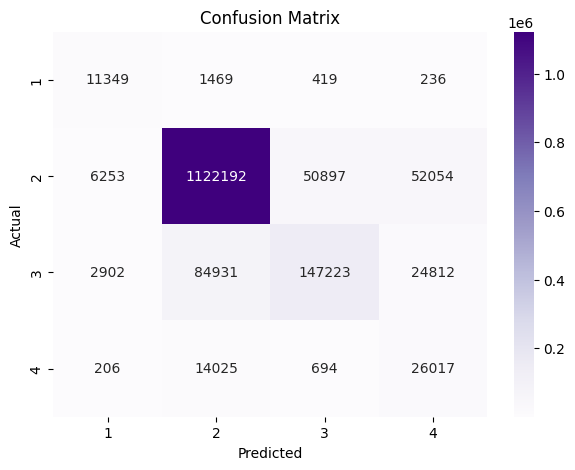

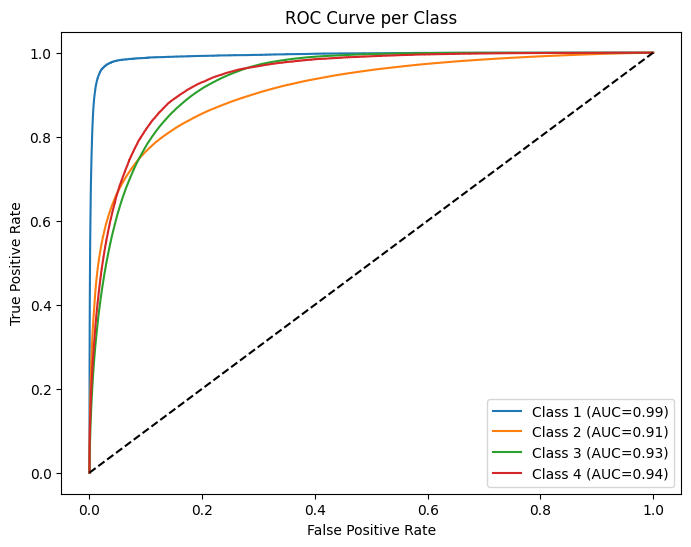

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


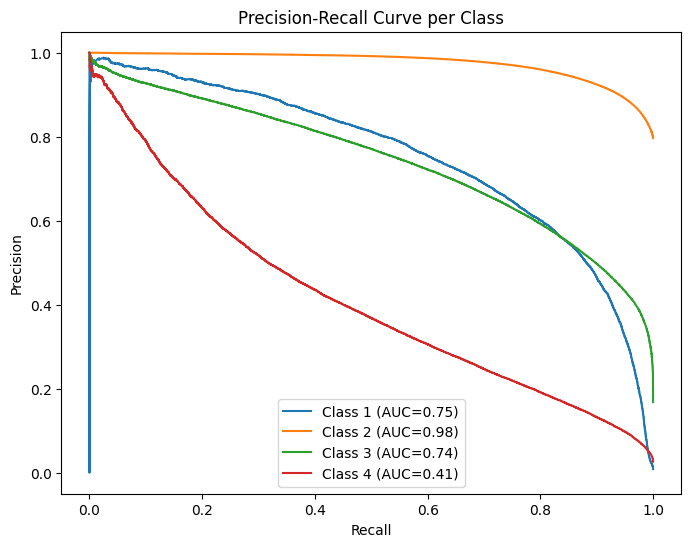

In [37]:
#  Evaluate
print("=== Classification Report ===")
print(classification_report(y_test_shift, y_pred_custom, digits=3))

# Confusion Matrix (purple palette)
cm = confusion_matrix(y_test_shift, y_pred_custom)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=[1,2,3,4], yticklabels=[1,2,3,4])
plt.xlabel('Predicted')

plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve per class
plt.figure(figsize=(8,6))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve((y_test_shift==cls).astype(int), y_proba[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {cls+1} (AUC={roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve per Class')
plt.legend()
plt.show()

# Precision-Recall Curve per class
plt.figure(figsize=(8,6))
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve((y_test_shift==cls).astype(int), y_proba[:,i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'Class {cls+1} (AUC={pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve per Class')
plt.legend()
plt.show()


In [39]:
# Shift target labels for XGBoost
y_train_shift = (y_train_bal - 1).astype(int)
y_test_shift = (y_test - 1).astype(int)

# Sample weights for XGBoost
# Define class weights
class_weights_dict = {
    0: 3,   # class 0 (minor)
    1: 1.5, # class 1 (major)
    2: 2,   # class 2
    3: 5    # class 4 (minor)
}
sample_weights = y_train_shift.map(class_weights_dict).values  # 0=class1, 1=class2, 2=class3, 3=class4

# Train XGBoost
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb.fit(X_train_bal, y_train_shift, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1, num_class=4, ...)

In [40]:
#  Threshold-based predictions with margin to avoid cheating
thresholds = {
    0: 0.4,  # increase recall of class 0
    1: 0.6,  # increase precision of class 1
    2: 0.5,
    3: 0.35  # balance precision/recall for class 4
}
y_proba = xgb.predict_proba(X_test)
classes = sorted(y_test.unique())

classes = sorted(y_test_shift.unique())
y_pred_custom = []
for probs in y_proba:
    above_thresh = [cls for i, cls in enumerate(classes) if probs[i] >= thresholds[cls]]
    if len(above_thresh) == 0:
        chosen_class = classes[np.argmax(probs)]
    elif len(above_thresh) == 1:
        chosen_class = above_thresh[0]
    else:
        indices = [cls for cls in above_thresh]
        chosen_class = above_thresh[np.argmax([probs[i] for i in indices])]
    y_pred_custom.append(chosen_class)
y_pred_custom = np.array(y_pred_custom)



=== Classification Report ===
              precision    recall  f1-score   support

           0      0.626     0.772     0.691     13473
           1      0.924     0.908     0.916   1231396
           2      0.698     0.661     0.679    259868
           3      0.321     0.569     0.411     40942

    accuracy                          0.857   1545679
   macro avg      0.642     0.728     0.674   1545679
weighted avg      0.867     0.857     0.861   1545679



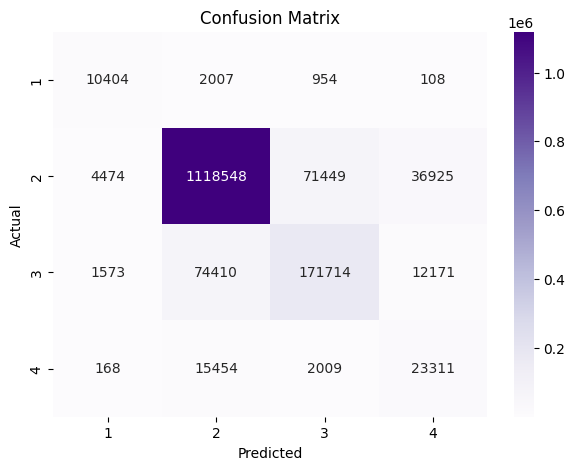

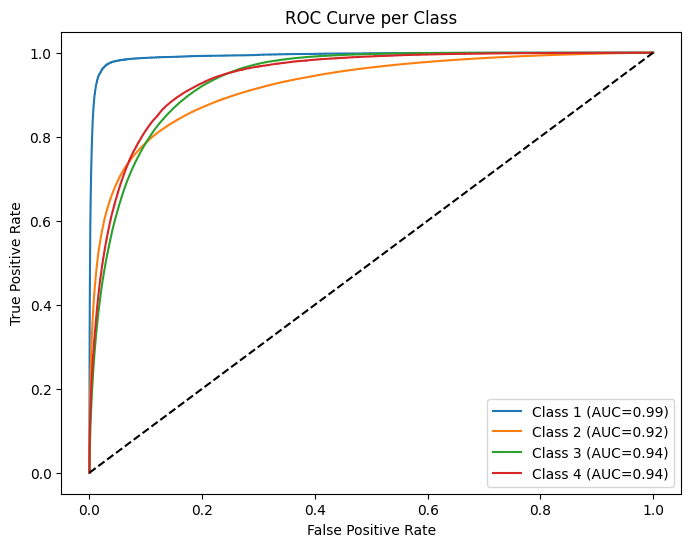

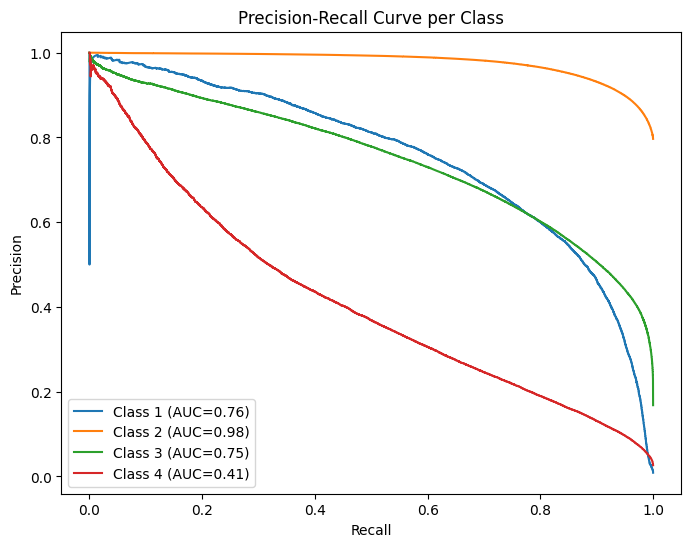

In [41]:
# 15. Evaluate
# ==============================
print("=== Classification Report ===")
print(classification_report(y_test_shift, y_pred_custom, digits=3))

# Confusion Matrix (purple palette)
cm = confusion_matrix(y_test_shift, y_pred_custom)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=[1,2,3,4], yticklabels=[1,2,3,4])
plt.xlabel('Predicted')

plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve per class
plt.figure(figsize=(8,6))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve((y_test_shift==cls).astype(int), y_proba[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {cls+1} (AUC={roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve per Class')
plt.legend()
plt.show()

# Precision-Recall Curve per class
plt.figure(figsize=(8,6))
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve((y_test_shift==cls).astype(int), y_proba[:,i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'Class {cls+1} (AUC={pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve per Class')
plt.legend()
plt.show()


In [42]:
#  Threshold-based predictions with margin to avoid cheating
thresholds = {
    0: 0.4,  # increase recall of class 0
    1: 0.6,  # increase precision of class 1
    2: 0.5,
    3: 0.5  # balance precision/recall for class 4
}
y_proba = xgb.predict_proba(X_test)
classes = sorted(y_test.unique())

classes = sorted(y_test_shift.unique())
y_pred_custom = []
for probs in y_proba:
    above_thresh = [cls for i, cls in enumerate(classes) if probs[i] >= thresholds[cls]]
    if len(above_thresh) == 0:
        chosen_class = classes[np.argmax(probs)]
    elif len(above_thresh) == 1:
        chosen_class = above_thresh[0]
    else:
        indices = [cls for cls in above_thresh]
        chosen_class = above_thresh[np.argmax([probs[i] for i in indices])]
    y_pred_custom.append(chosen_class)

=== Classification Report ===
              precision    recall  f1-score   support

           0      0.626     0.772     0.691     13473
           1      0.922     0.919     0.920   1231396
           2      0.697     0.665     0.680    259868
           3      0.371     0.481     0.419     40942

    accuracy                          0.863   1545679
   macro avg      0.654     0.709     0.678   1545679
weighted avg      0.867     0.863     0.865   1545679



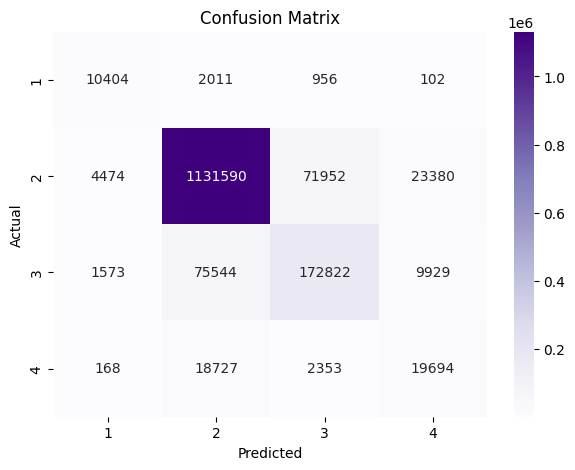

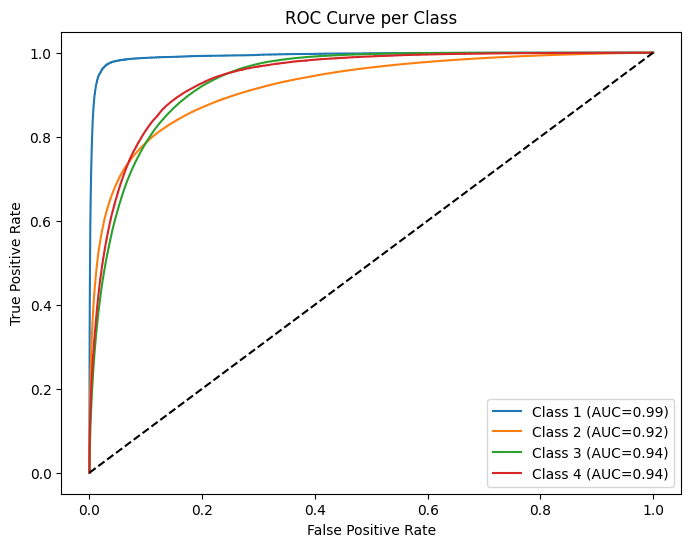

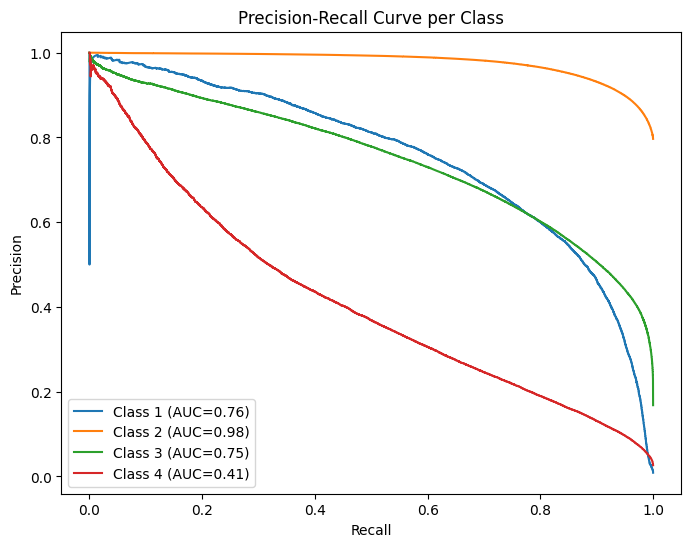

In [43]:
#  Evaluate
print("=== Classification Report ===")
print(classification_report(y_test_shift, y_pred_custom, digits=3))

# Confusion Matrix (purple palette)
cm = confusion_matrix(y_test_shift, y_pred_custom)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=[1,2,3,4], yticklabels=[1,2,3,4])
plt.xlabel('Predicted')

plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve per class
plt.figure(figsize=(8,6))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve((y_test_shift==cls).astype(int), y_proba[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {cls+1} (AUC={roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve per Class')
plt.legend()
plt.show()

# Precision-Recall Curve per class
plt.figure(figsize=(8,6))
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve((y_test_shift==cls).astype(int), y_proba[:,i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'Class {cls+1} (AUC={pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve per Class')
plt.legend()
plt.show()


In [50]:
# Shift target labels for XGBoost
# ==============================
y_train_shift = (y_train_bal - 1).astype(int)
y_test_shift = (y_test - 1).astype(int)

#  Sample weights for XGBoost
# Define class weights
class_weights_dict = {
    0: 3,   # class 0 (minor)
    1: 1.5, # class 1 (major)
    2: 2,   # class 2
    3: 8    # class 4 (minor)
}
sample_weights = y_train_shift.map(class_weights_dict).values  # 0=class1, 1=class2, 2=class3, 3=class4

# Train XGBoost
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb.fit(X_train_bal, y_train_shift, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1, num_class=4, ...)

In [51]:
# Threshold-based predictions with margin to avoid cheating
thresholds = {
    0:0.6,
    1:0.1,
    2:0.5,
    3:0.7
}
y_proba = xgb.predict_proba(X_test)
classes = sorted(y_test.unique())

classes = sorted(y_test_shift.unique())
y_pred_custom = []
for probs in y_proba:
    above_thresh = [cls for i, cls in enumerate(classes) if probs[i] >= thresholds[cls]]
    if len(above_thresh) == 0:
        chosen_class = classes[np.argmax(probs)]
    elif len(above_thresh) == 1:
        chosen_class = above_thresh[0]
    else:
        indices = [cls for cls in above_thresh]
        chosen_class = above_thresh[np.argmax([probs[i] for i in indices])]
    y_pred_custom.append(chosen_class)

=== Classification Report ===
              precision    recall  f1-score   support

           0      0.771     0.587     0.666     13473
           1      0.902     0.939     0.920   1231396
           2      0.711     0.623     0.664    259868
           3      0.493     0.310     0.381     40942

    accuracy                          0.866   1545679
   macro avg      0.719     0.615     0.658   1545679
weighted avg      0.858     0.866     0.861   1545679



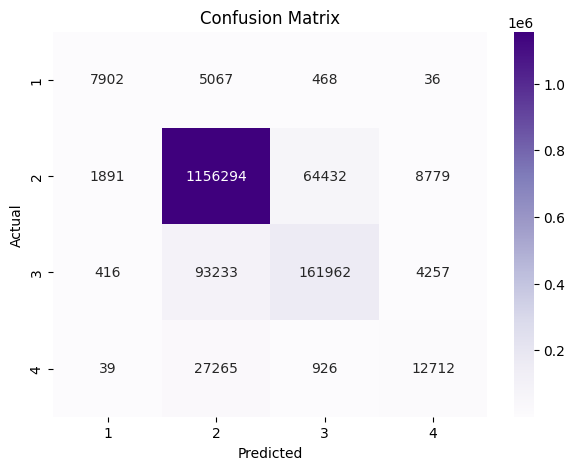

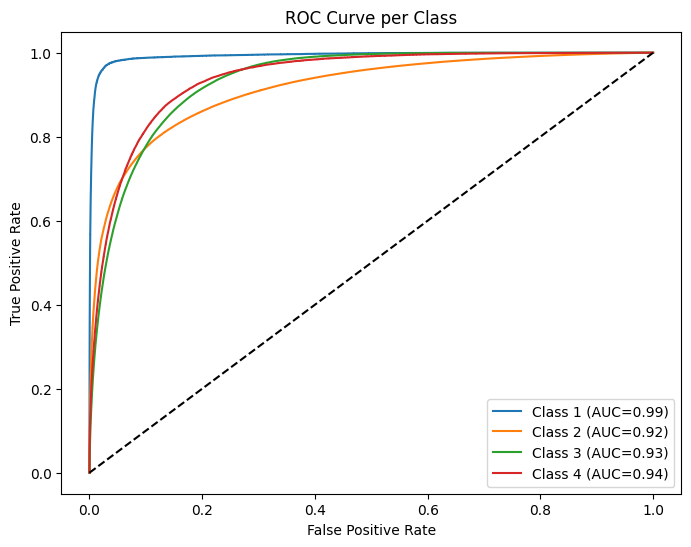

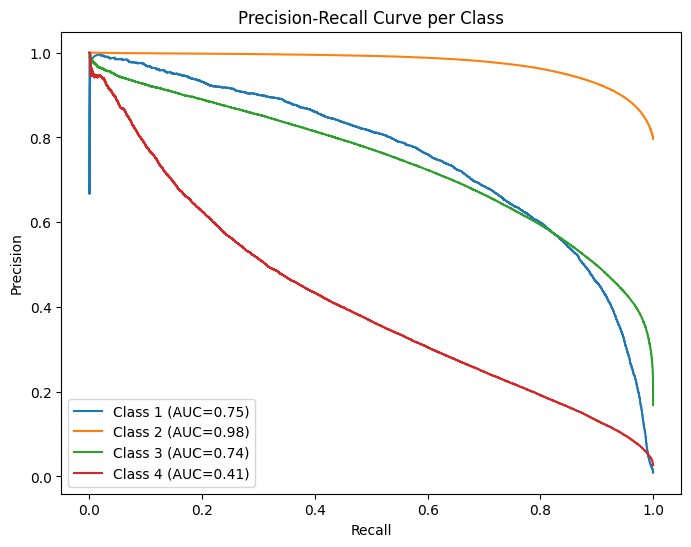

In [52]:
#  Evaluate
print("=== Classification Report ===")
print(classification_report(y_test_shift, y_pred_custom, digits=3))

# Confusion Matrix (purple palette)
cm = confusion_matrix(y_test_shift, y_pred_custom)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=[1,2,3,4], yticklabels=[1,2,3,4])
plt.xlabel('Predicted')

plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve per class
plt.figure(figsize=(8,6))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve((y_test_shift==cls).astype(int), y_proba[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {cls+1} (AUC={roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve per Class')
plt.legend()
plt.show()

# Precision-Recall Curve per class
plt.figure(figsize=(8,6))
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve((y_test_shift==cls).astype(int), y_proba[:,i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'Class {cls+1} (AUC={pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve per Class')
plt.legend()
plt.show()


In [21]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier

In [22]:
models = {

"xgboost": XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
),

"lightgbm": LGBMClassifier(
    objective='multiclass',
    num_class=4,
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
),

"catboost": CatBoostClassifier(
    loss_function='MultiClass',
    iterations=300,
    depth=8,
    learning_rate=0.05,
    random_state=42,
    verbose=0
),

"neural_net": MLPClassifier(
    hidden_layer_sizes=(256,128),
    activation='relu',
    solver='adam',
    batch_size=4096,
    learning_rate_init=0.001,
    max_iter=20,
    random_state=42
)

}

In [23]:
def threshold_predict(model, X, thresholds):

    proba = model.predict_proba(X)
    classes = list(range(proba.shape[1]))

    preds = []

    for probs in proba:

        above = [c for c in classes if probs[c] >= thresholds[c]]

        if len(above) == 0:
            preds.append(np.argmax(probs))

        elif len(above) == 1:
            preds.append(above[0])

        else:
            preds.append(above[np.argmax([probs[c] for c in above])])

    return np.array(preds)

In [26]:
y_train_shift = (y_train_bal - 1).astype(int)
y_test_shift = (y_test - 1).astype(int)

class_weights_dict = {
    0: 3,   # class 0 (minor)
    1: 1.5, # class 1 (major)
    2: 2,   # class 2
    3: 5    # class 4 (minor)
}
sample_weights = y_train_shift.map(class_weights_dict).values

In [27]:
thresholds = {
    0: 0.4,  # increase recall of class 0
    1: 0.6,  # increase precision of class 1
    2: 0.5,
    3: 0.35  # balance precision/recall for class 4
}

In [28]:
from sklearn.metrics import classification_report, f1_score

results = {}

for name, model in models.items():

    print(f"\nTraining {name} ...")

    if name == "neural_net":
        model.fit(X_train_bal, y_train_shift)
    else:
        model.fit(X_train_bal, y_train_shift,
                  sample_weight=sample_weights)

    y_pred = threshold_predict(model, X_test, thresholds)

    f1 = f1_score(y_test_shift, y_pred, average='weighted')

    results[name] = f1

    print("F1 weighted:", f1)
    print(classification_report(y_test_shift, y_pred))


Training xgboost ...
F1 weighted: 0.8608517182852286
              precision    recall  f1-score   support

           0       0.63      0.77      0.69     13473
           1       0.92      0.91      0.92   1231396
           2       0.70      0.66      0.68    259868
           3       0.32      0.57      0.41     40942

    accuracy                           0.86   1545679
   macro avg       0.64      0.73      0.67   1545679
weighted avg       0.87      0.86      0.86   1545679


Training lightgbm ...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.600171 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2865
[LightGBM] [Info] Number of data points in the train set: 6218947, number of used features: 45
[LightGBM] [Info] Start training from score -4.185728
[LightGBM] [Info] Start training from score -0.363677
[LightGBM] [Info] Start t

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


F1 weighted: 0.8546065579964865
              precision    recall  f1-score   support

           0       0.65      0.60      0.63     13473
           1       0.90      0.94      0.92   1231396
           2       0.70      0.59      0.64    259868
           3       0.44      0.31      0.36     40942

    accuracy                           0.86   1545679
   macro avg       0.67      0.61      0.64   1545679
weighted avg       0.85      0.86      0.85   1545679



In [33]:
# Convert to dataframe
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['F1_macro'])
results_df = results_df.sort_values('F1_macro', ascending=False)

print(results_df)

            F1_macro
xgboost     0.860852
lightgbm    0.854781
neural_net  0.854607
catboost    0.847727


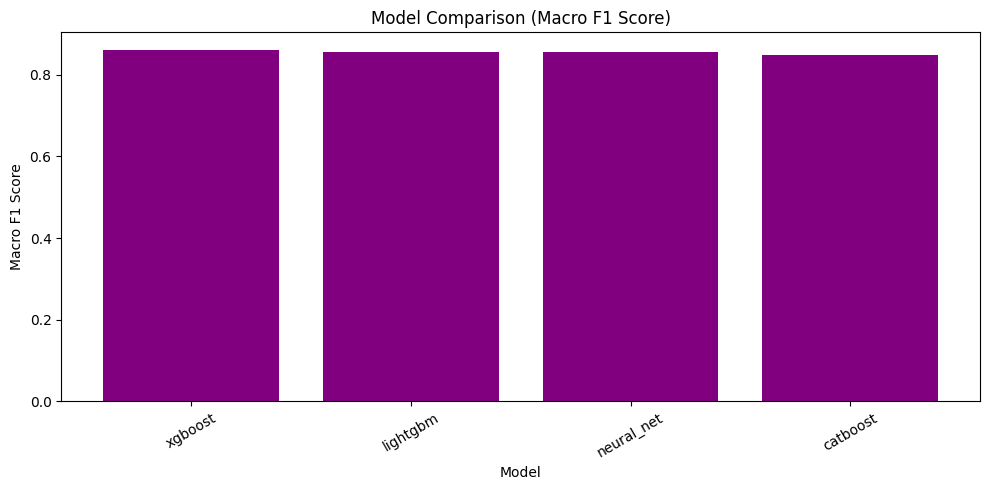

In [30]:
plt.figure(figsize=(10,5))
plt.bar(results_df.index, results_df['F1_macro'],
        color='purple')

plt.title('Model Comparison (Macro F1 Score)')
plt.xlabel('Model')
plt.ylabel('Macro F1 Score')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

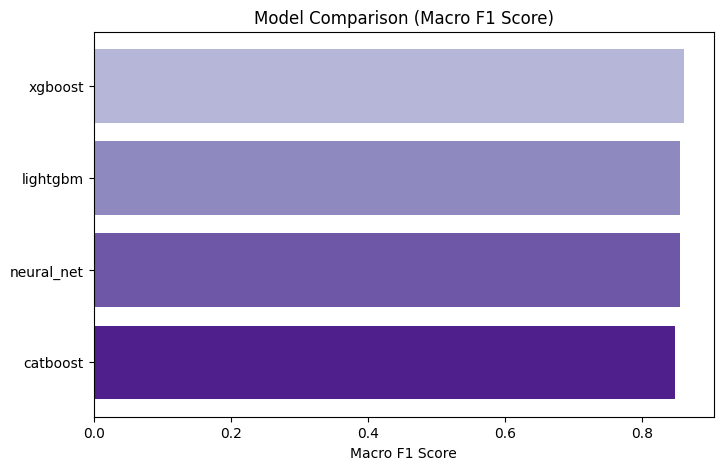

In [31]:
colors = plt.cm.Purples(np.linspace(0.4, 0.9, len(results_df)))

plt.figure(figsize=(8,5))
plt.barh(results_df.index, results_df['F1_macro'],
         color=colors)

plt.title('Model Comparison (Macro F1 Score)')
plt.xlabel('Macro F1 Score')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# from sklearn.metrics import classification_report, confusion_matrix, fbeta_score, recall_score, make_scorer, roc_curve, auc, precision_recall_curve

# # 8. Class Weights & Mapping
# # ============================================
# class_weights_dict = {0: 20, 1: 1, 2: 3, 3: 20}  # Custom weights
# sample_weights = np.array([class_weights_dict[y] for y in y_train_mapped])

# # Custom scorer for Class 4 recall
# recall_class4_scorer = make_scorer(recall_score, labels=[3], average='macro')

In [ ]:
# # ============================================
# # 7. Map Classes to 0-based Index
# # ============================================
# class_mapping = {1:0, 2:1, 3:2, 4:3}
# y_train_idx = y_train_bal.map(class_mapping).values
# y_test_idx = y_test.map(class_mapping).values

# # ============================================
# # 8. Compute Class Weights
# # ============================================
# classes = np.unique(y_train_idx)
# weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_idx)
# class_weights = {i:w for i,w in zip(classes, weights)}
# sample_weights = np.array([class_weights[i] for i in y_train_idx])

# # ============================================
# # 9. Stage-wise XGBoost
# # ============================================
# # Stage 1: Minor (1&2) vs Critical (3&4)
# y_train_stage1 = np.where(y_train_idx<=1, 0, 1)
# y_test_stage1 = np.where(y_test_idx<=1, 0, 1)
# sample_weights_stage1 = np.where(y_train_stage1==1, 3, 1)

# xgb_stage1 = XGBClassifier(
#     n_estimators=300, max_depth=8, learning_rate=0.05,
#     subsample=0.8, colsample_bytree=0.8, tree_method='hist',
#     objective='binary:logistic', eval_metric='logloss',
#     random_state=RANDOM_STATE
# )
# xgb_stage1.fit(X_train_scaled, y_train_stage1, sample_weight=sample_weights_stage1)
# y_prob_stage1 = xgb_stage1.predict_proba(X_test_scaled)[:,1]
# threshold_stage1 = 0.5
# y_pred_stage1 = (y_prob_stage1>=threshold_stage1).astype(int)

# # Stage 2: Sub-classification
# minor_idx_train = np.where(y_train_stage1==0)[0]
# critical_idx_train = np.where(y_train_stage1==1)[0]
# minor_idx_test = np.where(y_pred_stage1==0)[0]
# critical_idx_test = np.where(y_pred_stage1==1)[0]

# # Minor classifier (Class 1 vs Class 2)
# y_train_minor = y_train_idx[minor_idx_train]
# X_train_minor = X_train_scaled.iloc[minor_idx_train]
# xgb_minor = XGBClassifier(
#     n_estimators=200, max_depth=6, learning_rate=0.05,
#     subsample=0.8, colsample_bytree=0.8, tree_method='hist',
#     objective='binary:logistic', eval_metric='logloss', random_state=RANDOM_STATE
# )
# xgb_minor.fit(X_train_minor, (y_train_minor==1).astype(int))
# y_prob_minor = xgb_minor.predict_proba(X_test_scaled.iloc[minor_idx_test])[:,1]
# y_pred_minor_final = (y_prob_minor>=0.5).astype(int)

# # Critical classifier (Class 3 vs Class 4) with Class 4 weighting
# y_train_critical = y_train_idx[critical_idx_train]
# X_train_critical = X_train_scaled.iloc[critical_idx_train]
# sample_weights_critical = np.where(y_train_critical==3, 10, 1)
# xgb_critical = XGBClassifier(
#     n_estimators=200, max_depth=6, learning_rate=0.05,
#     subsample=0.8, colsample_bytree=0.8, tree_method='hist',
#     objective='binary:logistic', eval_metric='logloss', random_state=RANDOM_STATE
# )
# xgb_critical.fit(X_train_critical, (y_train_critical==3).astype(int), sample_weight=sample_weights_critical)
# y_prob_critical = xgb_critical.predict_proba(X_test_scaled.iloc[critical_idx_test])[:,1]

# # Optimize Class 4 threshold
# def optimize_class_threshold(y_true, y_prob, beta=1):
#     best_thresh = 0.5
#     best_score = 0
#     for t in np.arange(0.1, 0.91, 0.01):
#         y_pred = (y_prob >= t).astype(int)
#         score = fbeta_score(y_true, y_pred, beta=beta, average='binary')
#         if score > best_score:
#             best_score = score
#             best_thresh = t
#     return best_thresh

# y_test_critical_orig = (y_test_idx[critical_idx_test]==3).astype(int)
# threshold_class4 = optimize_class_threshold(y_test_critical_orig, y_prob_critical, beta=1)
# y_pred_critical_final = (y_prob_critical>=threshold_class4).astype(int)

# # ============================================
# # 10. Combine Stage Predictions
# # ============================================
# y_pred_final = np.zeros_like(y_test_idx)
# y_pred_final[minor_idx_test] = np.where(y_pred_minor_final==1,1,0)
# y_pred_final[critical_idx_test] = np.where(y_pred_critical_final==1,3,2)

# # ============================================
# # 11. Evaluation
# # ============================================
# print("Classification Report:")
# print(classification_report(y_test_idx, y_pred_final,
#                             target_names=['Class 1','Class 2','Class 3','Class 4'], digits=3))

# cm = confusion_matrix(y_test_idx, y_pred_final)
# plt.figure(figsize=(6,5))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# plt.title("Confusion Matrix")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()

# # ROC & Precision-Recall Curves
# y_test_bin = label_binarize(y_test_idx, classes=[0,1,2,3])
# y_prob_full = np.zeros_like(y_test_bin, dtype=float)
# y_prob_full[minor_idx_test,0] = 1 - y_prob_minor
# y_prob_full[minor_idx_test,1] = y_prob_minor
# y_prob_full[critical_idx_test,2] = 1 - y_prob_critical
# y_prob_full[critical_idx_test,3] = y_prob_critical

# plt.figure(figsize=(12,5))
# plt.subplot(1,2,1)
# for i in range(4):
#     fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_prob_full[:,i])
#     roc_auc = auc(fpr,tpr)
#     plt.plot(fpr,tpr,label=f'Class {i+1} (AUC={roc_auc:.2f})')
# plt.plot([0,1],[0,1],'k--')
# plt.title("ROC Curves")
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.legend(loc='lower right')

# plt.subplot(1,2,2)
# for i in range(4):
#     precision, recall, _ = precision_recall_curve(y_test_bin[:,i], y_prob_full[:,i])
#     plt.plot(recall, precision, label=f'Class {i+1}')
# plt.title("Precision-Recall Curves")
# plt.xlabel("Recall")
# plt.ylabel("Precision")
# plt.legend(loc='lower left')
# plt.tight_layout()
# plt.show()

In [ ]:
# # ============================================
# # 7. Map Classes to 0-based Index
# # ============================================
# class_mapping = {1:0, 2:1, 3:2, 4:3}
# y_train_idx = y_train_bal.map(class_mapping).values
# y_test_idx = y_test.map(class_mapping).values

# # ============================================
# # 8. Class Weights
# # ============================================
# class_weights = {0:20, 1:1, 2:3, 3:20}
# sample_weights = np.array([class_weights[i] for i in y_train_idx])

# # ============================================
# # 9. Stage-wise XGBoost
# # ============================================
# # Stage 1: Minor (1&2) vs Critical (3&4)
# y_train_stage1 = np.where(y_train_idx<=1, 0, 1)
# y_test_stage1 = np.where(y_test_idx<=1, 0, 1)
# sample_weights_stage1 = np.where(y_train_stage1==0, class_weights[0], class_weights[1])
# xgb_stage1 = XGBClassifier(
#     n_estimators=300, max_depth=8, learning_rate=0.05,
#     subsample=0.8, colsample_bytree=0.8, tree_method='hist',
#     objective='binary:logistic', eval_metric='logloss',
#     random_state=RANDOM_STATE
# )
# xgb_stage1.fit(X_train_scaled, y_train_stage1, sample_weight=sample_weights_stage1)
# y_prob_stage1 = xgb_stage1.predict_proba(X_test_scaled)[:,1]
# y_pred_stage1 = (y_prob_stage1>=0.5).astype(int)

# # Stage 2: Minor classifier (Class 1 vs Class 2)
# minor_idx_test = np.where(y_pred_stage1==0)[0]
# minor_idx_train = np.where(y_train_stage1==0)[0]
# X_train_minor = X_train_scaled.iloc[minor_idx_train]
# y_train_minor = y_train_idx[minor_idx_train]
# xgb_minor = XGBClassifier(n_estimators=200,max_depth=6,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,
#                           tree_method='hist',objective='binary:logistic', eval_metric='logloss', random_state=RANDOM_STATE)
# xgb_minor.fit(X_train_minor, (y_train_minor==1).astype(int))
# y_prob_minor = xgb_minor.predict_proba(X_test_scaled.iloc[minor_idx_test])[:,1]

# # Optimize threshold for Class 1 to improve precision
# def optimize_threshold(y_true, y_prob, beta=1):
#     best_thresh = 0.5
#     best_score = 0
#     for t in np.arange(0.1,0.91,0.01):
#         y_pred = (y_prob>=t).astype(int)
#         score = fbeta_score(y_true, y_pred, beta=beta, average='binary')
#         if score>best_score:
#             best_score = score
#             best_thresh = t
#     return best_thresh

# y_test_minor_orig = (y_test_idx[minor_idx_test]==1).astype(int)
# threshold_class1 = optimize_threshold(y_test_minor_orig, y_prob_minor, beta=1)
# y_pred_minor_final = (y_prob_minor>=threshold_class1).astype(int)

# # Stage 2: Critical classifier (Class 3 vs Class 4)
# critical_idx_test = np.where(y_pred_stage1==1)[0]
# critical_idx_train = np.where(y_train_stage1==1)[0]
# X_train_critical = X_train_scaled.iloc[critical_idx_train]
# y_train_critical = y_train_idx[critical_idx_train]
# sample_weights_critical = np.where(y_train_critical==3, class_weights[3], class_weights[2])
# xgb_critical = XGBClassifier(n_estimators=200,max_depth=6,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,
#                              tree_method='hist',objective='binary:logistic', eval_metric='logloss', random_state=RANDOM_STATE)
# xgb_critical.fit(X_train_critical, (y_train_critical==3).astype(int), sample_weight=sample_weights_critical)
# y_prob_critical = xgb_critical.predict_proba(X_test_scaled.iloc[critical_idx_test])[:,1]
# y_test_critical_orig = (y_test_idx[critical_idx_test]==3).astype(int)
# threshold_class4 = optimize_threshold(y_test_critical_orig, y_prob_critical, beta=1)
# y_pred_critical_final = (y_prob_critical>=threshold_class4).astype(int)

# # ============================================
# # 10. Combine Predictions
# # ============================================
# y_pred_final = np.zeros_like(y_test_idx)
# y_pred_final[minor_idx_test] = np.where(y_pred_minor_final==1,1,0)
# y_pred_final[critical_idx_test] = np.where(y_pred_critical_final==1,3,2)

# # ============================================
# # 11. Evaluation
# # ============================================
# print("Classification Report:")
# print(classification_report(y_test_idx, y_pred_final,
#                             target_names=['Class 1','Class 2','Class 3','Class 4'], digits=3))

# cm = confusion_matrix(y_test_idx, y_pred_final)
# plt.figure(figsize=(6,5))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# plt.title("Confusion Matrix")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()

# # ROC & Precision-Recall Curves
# y_test_bin = label_binarize(y_test_idx, classes=[0,1,2,3])
# y_prob_full = np.zeros_like(y_test_bin, dtype=float)
# y_prob_full[minor_idx_test,0] = 1 - y_prob_minor
# y_prob_full[minor_idx_test,1] = y_prob_minor
# y_prob_full[critical_idx_test,2] = 1 - y_prob_critical
# y_prob_full[critical_idx_test,3] = y_prob_critical

# plt.figure(figsize=(12,5))
# plt.subplot(1,2,1)
# for i in range(4):
#     fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_prob_full[:,i])
#     roc_auc = auc(fpr,tpr)
#     plt.plot(fpr,tpr,label=f'Class {i+1} (AUC={roc_auc:.2f})')
# plt.plot([0,1],[0,1],'k--')
# plt.title("ROC Curves")
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.legend(loc='lower right')

# plt.subplot(1,2,2)
# for i in range(4):
#     precision, recall, _ = precision_recall_curve(y_test_bin[:,i], y_prob_full[:,i])
#     plt.plot(recall, precision, label=f'Class {i+1}')
# plt.title("Precision-Recall Curves")
# plt.xlabel("Recall")
# plt.ylabel("Precision")
# plt.legend(loc='lower left')
# plt.tight_layout()
# plt.show()

In [ ]:

# # ============================================
# # Map Classes to 0-based Index
# # ============================================
# class_mapping = {1:0, 2:1, 3:2, 4:3}
# y_train_idx = y_train_bal.map(class_mapping).values
# y_test_idx = y_test.map(class_mapping).values

# # ============================================
# # Class weights to improve minority recall
# # ============================================
# class_weights = {0:5, 1:1, 2:15, 3:20}  # Aggressive for Class 3 and 4
# sample_weights = np.array([class_weights[i] for i in y_train_idx])

# # ============================================
# # Train One-vs-Rest XGBoost for all classes
# # ============================================
# n_classes = 4
# y_train_bin = label_binarize(y_train_idx, classes=range(n_classes))
# y_test_bin = label_binarize(y_test_idx, classes=range(n_classes))

# y_prob_all = np.zeros_like(y_test_bin, dtype=float)

# for i in range(n_classes):
#     xgb = XGBClassifier(
#         n_estimators=300, max_depth=6, learning_rate=0.05,
#         subsample=0.8, colsample_bytree=0.8, tree_method='hist',
#         objective='binary:logistic', eval_metric='logloss', random_state=RANDOM_STATE
#     )
#     w = np.where(y_train_bin[:,i]==1, class_weights[i],1)
#     xgb.fit(X_train_scaled, y_train_bin[:,i], sample_weight=w)
#     y_prob_all[:,i] = xgb.predict_proba(X_test_scaled)[:,1]

# # ============================================
# # Optimize thresholds for Class 3 & Class 4 to increase recall
# # ============================================
# thresholds = [0.5]*4
# for i in [2,3]:  # Class 3 & 4
#     best_thresh = 0.5
#     best_score = 0
#     for t in np.arange(0.1,0.91,0.01):
#         y_pred = (y_prob_all[:,i]>=t).astype(int)
#         score = fbeta_score(y_test_bin[:,i], y_pred, beta=2)  # prioritize recall
#         if score>best_score:
#             best_score=score
#             best_thresh=t
#     thresholds[i] = best_thresh

# y_pred_final = np.argmax(y_prob_all>=thresholds, axis=1)

# # ============================================
# # Evaluation
# # ============================================
# print("Classification Report:")
# print(classification_report(y_test_idx, y_pred_final,
#                             target_names=['Class 1','Class 2','Class 3','Class 4'], digits=3))

# cm = confusion_matrix(y_test_idx, y_pred_final)
# plt.figure(figsize=(6,5))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# plt.title("Confusion Matrix")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()

# # ROC & Precision-Recall curves
# plt.figure(figsize=(12,5))
# plt.subplot(1,2,1)
# for i in range(n_classes):
#     fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_prob_all[:,i])
#     plt.plot(fpr,tpr,label=f'Class {i+1}')
# plt.plot([0,1],[0,1],'k--')
# plt.title("ROC Curves")
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.legend()

# plt.subplot(1,2,2)
# for i in range(n_classes):
#     precision, recall, _ = precision_recall_curve(y_test_bin[:,i], y_prob_all[:,i])
#     plt.plot(recall, precision, label=f'Class {i+1}')
# plt.title("Precision-Recall Curves")
# plt.xlabel("Recall")
# plt.ylabel("Precision")
# plt.legend()
# plt.tight_layout()
# plt.show()

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import classification_report

# 1. SETUP FEATURES
# We assume 'City' is your only categorical, others are numeric
target_col = 'Severity'
cat_features = ['City']
num_features = ['Start_Lat', 'Start_Lng', 'Temperature(F)', 'Humidity(%)', 'Visibility(mi)']

# 2. TARGET ENCODER WITH SMOOTHING
# Smoothing is CRITICAL: it prevents the model from over-relying on 
# cities that only had 1 or 2 accidents.
target_enc = TargetEncoder(
    cols=cat_features, 
    smoothing=20.0, 
    handle_missing='value'
)

# 3. COLUMN TRANSFORMER
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('city_risk', target_enc, cat_features)
    ],
    remainder='drop' 
)

# 4. FULL PIPELINE (Imbalance-Aware)
# We use RandomUnderSampler to handle your 6.2M 'Severity 2' rows
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('sampler', RandomUnderSampler(sampling_strategy='auto', random_state=42)),
    ('classifier', xgb.XGBClassifier(
        tree_method='hist',      # Histogram method is 10x faster for 7M rows
        device="cuda",           # Use "cpu" if you don't have an NVIDIA GPU
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        objective='multi:softmax',
        num_class=4,
        n_jobs=-1                # Use all CPU cores
    ))
])

# 5. EXECUTION STRATEGY
# Ensure Severity is 0-indexed (0, 1, 2, 3) for XGBoost
# X_train, X_test, y_train, y_test = train_test_split(X, y - 1, test_size=0.2, stratify=y)

print("Starting training on 7M rows...")
pipeline.fit(X_train, y_train)

# 6. EVALUATION
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

In [ ]:
# ==============================
# 1. Imports
# ==============================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, precision_recall_curve, auc, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# 2. Config
# ==============================
RANDOM_STATE = 42
TEST_SIZE = 0.2
TARGET_COL = "Severity"
CAT_COLS = ['City','Wind_Direction','Weather_Condition']
MAX_SAMPLES = {
    1: 100_000,   # minority, lightly oversample
    2: 400_000,   # majority, downsample
    3: 200_000,   # large, downsample
    4: 150_000    # minority, lightly oversample
}

In [ ]:
# 4. Cyclical features
# ==============================
def add_cyclical_features(df_encode):
    df_encode['Hour_Start_sin'] = np.sin(2*np.pi*df_encode['Hour_Start']/24)
    df_encode['Hour_Start_cos'] = np.cos(2*np.pi*df_encode['Hour_Start']/24)
    df_encode['Hour_End_sin'] = np.sin(2*np.pi*df_encode['Hour_End']/24)
    df_encode['Hour_End_cos'] = np.cos(2*np.pi*df_encode['Hour_End']/24)
    df_encode['Minutes_Start_sin'] = np.sin(2*np.pi*df_encode['Minutes_Start']/60)
    df_encode['Minutes_Start_cos'] = np.cos(2*np.pi*df_encode['Minutes_Start']/60)
    df_encode['Minutes_End_sin'] = np.sin(2*np.pi*df_encode['Minutes_End']/60)
    df_encode['Minutes_End_cos'] = np.cos(2*np.pi*df_encode['Minutes_End']/60)
    df_encode['Day_sin'] = np.sin(2*np.pi*df_encode['Day_of_Week']/7)
    df_encode['Day_cos'] = np.cos(2*np.pi*df_encode['Day_of_Week']/7)
    df_encode['Month_sin'] = np.sin(2*np.pi*df_encode['Month']/12)
    df_encode['Month_cos'] = np.cos(2*np.pi*df_encode['Month']/12)
    df_encode.drop(['Hour_Start','Hour_End','Minutes_Start','Minutes_End','Day_of_Week','Month'], axis=1, inplace=True, errors='ignore')
    return df_encode

df_encode = add_cyclical_features(df_encode)

In [ ]:
# 5. Train-test split
# ==============================
X = df_encode.drop(TARGET_COL, axis=1)
y = df_encode[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

In [ ]:
# 6. Behavior-based sampling
# ==============================
def behavior_sample(df, target_class, max_samples=None, upsample=False):
    subset = df[df[TARGET_COL]==target_class].copy()
    others = df[df[TARGET_COL]!=target_class].copy()
    
    # Encode categorical columns temporarily for hashing
    behavior_cols = list(subset.select_dtypes(include=np.number).columns) + ['Wind_Direction','Weather_Condition']
    for col in ['Wind_Direction','Weather_Condition']:
        subset[col] = subset[col].astype('category').cat.codes
    
    arr = subset[behavior_cols].to_numpy()
    _, idx = np.unique(arr, axis=0, return_index=True)
    subset_unique = subset.iloc[idx].copy()
    
    # Upsample if needed
    if upsample and max_samples is not None and len(subset_unique) < max_samples:
        n_repeat = int(np.ceil(max_samples / len(subset_unique)))
        subset_unique = pd.concat([subset_unique]*n_repeat, ignore_index=True).sample(max_samples, random_state=RANDOM_STATE)
    
    # Downsample if needed
    if not upsample and max_samples is not None and len(subset_unique) > max_samples:
        subset_unique = subset_unique.sample(max_samples, random_state=RANDOM_STATE)
    
    return pd.concat([subset_unique, others], ignore_index=True)


In [ ]:
# Combine features and target for sampling
train_bal = pd.concat([X_train, y_train], axis=1)

# Apply proportional behavior-based sampling
for cls, max_count in MAX_SAMPLES.items():
    upsample = True if train_bal[TARGET_COL].value_counts()[cls] < max_count else False
    train_bal = behavior_sample(train_bal, target_class=cls, max_samples=max_count, upsample=upsample)

print("Class counts after proportional sampling:")
print(train_bal[TARGET_COL].value_counts())

In [ ]:
# 7. Separate features and target
# ==============================
X_train_bal = train_bal.drop(TARGET_COL, axis=1)
y_train_bal = train_bal[TARGET_COL]

# ==============================
# 8. Target encoding
# ==============================
cat_cols = X_train_bal.select_dtypes(include='object').columns.tolist()
num_cols = X_train_bal.select_dtypes(include=np.number).columns.tolist()

if len(cat_cols) > 0:
    te = TargetEncoder(cols=cat_cols)
    X_train_bal[cat_cols] = te.fit_transform(X_train_bal[cat_cols], y_train_bal)
    X_test[cat_cols] = te.transform(X_test[cat_cols])
# ==============================
# 9. Scale numeric features
# ==============================
scaler = StandardScaler()
X_train_bal[num_cols] = scaler.fit_transform(X_train_bal[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [ ]:
# ==============================
# 10. Shift labels for XGBoost
# ==============================
y_train_shift = (y_train_bal - 1).astype(int)
y_test_shift = (y_test - 1).astype(int)

# ==============================
# 11. Sample weights
# ==============================
weights = y_train_shift.map({0:5, 1:1, 2:2, 3:5}).to_numpy()

# ==============================
# 12. Train XGBoost
# ==============================
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb.fit(X_train_bal, y_train_shift, sample_weight=weights)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, precision_recall_curve, f1_score

# 13. Predict probabilities
# ==============================
y_test_proba = xgb.predict_proba(X_test)

# ==============================
# 14. Automatic threshold tuning per class
# ==============================
THRESHOLDS = {}
y_pred_auto = np.zeros_like(y_test_shift)

for cls in range(4):
    y_true_bin = (y_test_shift == cls).astype(int)
    best_f1 = 0
    best_thresh = 0.5
    for t in np.linspace(0.1, 0.9, 17):
        y_pred_bin = (y_test_proba[:,cls] >= t).astype(int)
        f1 = f1_score(y_true_bin, y_pred_bin)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = t
    THRESHOLDS[cls] = best_thresh
    print(f"Class {cls+1} best threshold: {best_thresh:.2f}, F1: {best_f1:.2f}")

# Apply thresholds
for i in range(len(y_test_shift)):
    probs = y_test_proba[i]
    candidates = [j for j, p in enumerate(probs) if p >= THRESHOLDS[j]]
    y_pred_auto[i] = max(candidates) if candidates else np.argmax(probs)

In [ ]:
# Initialize predictions
y_pred_final = np.zeros_like(y_test_shift)

for i in range(len(y_test_shift)):
    probs = y_test_proba[i]
    candidates = [j for j, p in enumerate(probs) if p >= THRESHOLDS[j]]
    # If no class meets threshold, fallback to class with highest probability
    y_pred_final[i] = max(candidates) if candidates else np.argmax(probs)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Accuracy
acc = accuracy_score(y_test_shift, y_pred_final)
print(f"Accuracy: {acc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test_shift, y_pred_final)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=[1,2,3,4], yticklabels=[1,2,3,4])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print(classification_report(y_test_shift, y_pred_final, target_names=['1','2','3','4']))

In [ ]:
# ROC curves
plt.figure(figsize=(8,6))
for i in range(4):
    fpr, tpr, _ = roc_curve((y_test_shift==i).astype(int), y_test_proba[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i+1} (AUC={roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve per Class')
plt.legend()
plt.show()

# Precision-Recall curves
plt.figure(figsize=(8,6))
for i in range(4):
    precision, recall, _ = precision_recall_curve((y_test_shift==i).astype(int), y_test_proba[:,i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'Class {i+1} (AUC={pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve per Class')
plt.legend()
plt.show()

In [ ]:
# # Downsample majority classes
# train_bal = pd.concat([X_train_full, y_train_full], axis=1)
# train_bal = behavior_sample(train_bal, target_class=2, max_samples=MAX_SAMPLES_PER_CLASS, upsample=False)
# train_bal = behavior_sample(train_bal, target_class=3, max_samples=MAX_SAMPLES_PER_CLASS, upsample=False)

# # Oversample minority classes
# train_bal = behavior_sample(train_bal, target_class=1, max_samples=MAX_SAMPLES_PER_CLASS, upsample=True)
# train_bal = behavior_sample(train_bal, target_class=4, max_samples=MAX_SAMPLES_PER_CLASS, upsample=True)

# # Check class distribution
# print("Class distribution after sampling:")
# print(train_bal[TARGET_COL].value_counts())

In [ ]:
# 7. Separate features and target
# ==============================
X_train_bal = train_bal.drop(TARGET_COL, axis=1)
y_train_bal = train_bal[TARGET_COL]

In [ ]:
# 8. Target encoding
# ==============================
cat_cols = X_train_bal.select_dtypes(include='object').columns.tolist()
num_cols = X_train_bal.select_dtypes(include=np.number).columns.tolist()

if len(cat_cols) > 0:
    te = TargetEncoder(cols=cat_cols)
    X_train_bal[cat_cols] = te.fit_transform(X_train_bal[cat_cols], y_train_bal)
    X_test[cat_cols] = te.transform(X_test[cat_cols])

In [ ]:
# 9. Scale numeric features
# ==============================
scaler = StandardScaler()
X_train_bal[num_cols] = scaler.fit_transform(X_train_bal[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


In [ ]:
# 10. Shift labels for XGBoost
# ==============================
y_train_shift = (y_train_bal - 1).astype(int)
y_test_shift = (y_test - 1).astype(int)

# ==============================
# 11. Sample weights
# ==============================
weights = y_train_shift.map({0:5, 1:1, 2:2, 3:5}).to_numpy()  # emphasize minority classes

# ==============================
# 12. Train XGBoost
# ==============================
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb.fit(X_train_bal, y_train_shift, sample_weight=weights)

In [ ]:
# 13. Predict with probability thresholds
# ==============================
y_test_proba = xgb.predict_proba(X_test)
# ==============================
# Per-class probability thresholds
# ==============================
# Keys = class labels (1-based), values = probability thresholds
THRESHOLDS = {1:0.5, 2:0.6, 3:0.5, 4:0.4}
# Apply per-class thresholds
y_pred_thresh = np.zeros_like(y_test_shift)
for i in range(len(y_test_shift)):
    probs = y_test_proba[i]
    candidates = [j for j, p in enumerate(probs) if p >= THRESHOLDS[j+1]]
    y_pred_thresh[i] = max(candidates) if candidates else np.argmax(probs)

In [ ]:
# 14. Evaluate
# ==============================
# Accuracy
acc = accuracy_score(y_test_shift, y_pred_thresh)
print(f"Accuracy: {acc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test_shift, y_pred_thresh)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=[1,2,3,4], yticklabels=[1,2,3,4])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification report
print(classification_report(y_test_shift, y_pred_thresh, target_names=['1','2','3','4']))

# ROC curves
plt.figure(figsize=(8,6))
for i in range(4):
    fpr, tpr, _ = roc_curve((y_test_shift==i).astype(int), y_test_proba[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i+1} (AUC={roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve per Class')
plt.legend()
plt.show()

# Precision-Recall curves
plt.figure(figsize=(8,6))
for i in range(4):
    precision, recall, _ = precision_recall_curve((y_test_shift==i).astype(int), y_test_proba[:,i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'Class {i+1} (AUC={pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve per Class')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score

from sklearn.utils.class_weight import compute_class_weight

from category_encoders import TargetEncoder

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

In [ ]:
# 3. Feature Engineering
# ============================================
df_encode['Hour_Start_sin'] = np.sin(2*np.pi*df_encode['Hour_Start']/24)
df_encode['Hour_Start_cos'] = np.cos(2*np.pi*df_encode['Hour_Start']/24)

df_encode['Hour_End_sin'] = np.sin(2*np.pi*df_encode['Hour_End']/24)
df_encode['Hour_End_cos'] = np.cos(2*np.pi*df_encode['Hour_End']/24)

df_encode['Minutes_Start_sin'] = np.sin(2*np.pi*df_encode['Minutes_Start']/60)
df_encode['Minutes_Start_cos'] = np.cos(2*np.pi*df_encode['Minutes_Start']/60)

df_encode['Minutes_End_sin'] = np.sin(2*np.pi*df_encode['Minutes_End']/60)
df_encode['Minutes_End_cos'] = np.cos(2*np.pi*df_encode['Minutes_End']/60)

df_encode['Day_sin'] = np.sin(2*np.pi*df_encode['Day_of_Week']/7)
df_encode['Day_cos'] = np.cos(2*np.pi*df_encode['Day_of_Week']/7)

df_encode['Month_sin'] = np.sin(2*np.pi*df_encode['Month']/12)
df_encode['Month_cos'] = np.cos(2*np.pi*df_encode['Month']/12)

df_encode.drop([
    'Hour_Start','Hour_End',
    'Minutes_Start','Minutes_End',
    'Day_of_Week','Month'
], axis=1, inplace=True, errors="ignore")


In [ ]:
df_encode.head(5)

In [ ]:
target = "Severity"

class1 = df_encode[df_encode[target]==1]
class2 = df_encode[df_encode[target]==2]
class3 = df_encode[df_encode[target]==3]
class4 = df_encode[df_encode[target]==4]

behavior_cols = [
    'City',
    'Weather_Condition',
    'Hour_Start_sin',
    'Day_sin',
    'Month_sin'
]

class2_down = (
    class2
    .groupby(behavior_cols,group_keys=False)
    .apply(lambda x: x.sample(min(len(x),2)))
)

df_balanced = pd.concat([class1,class2_down,class3,class4])

print(df_balanced[target].value_counts())

In [ ]:
X = df_balanced.drop(target,axis=1)
y = df_balanced[target]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
cat_cols = X_train.select_dtypes(include='object').columns

encoder = TargetEncoder(cols=cat_cols)

X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols],y_train)
X_test[cat_cols] = encoder.transform(X_test[cat_cols])